In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_excel("data/rule_data.xlsx")

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 50609 entries, 0 to 50608
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   uid                    50609 non-null  str           
 1   oil_actv_dt            50609 non-null  datetime64[us]
 2   create_dt              45665 non-null  datetime64[us]
 3   total_oil_cnt          46426 non-null  float64       
 4   pay_amount_total       46426 non-null  float64       
 5   class_new              50609 non-null  str           
 6   bad_ind                50609 non-null  int64         
 7   oil_amount             45665 non-null  float64       
 8   discount_amount        45665 non-null  float64       
 9   sale_amount            45665 non-null  float64       
 10  amount                 45665 non-null  float64       
 11  pay_amount             45665 non-null  float64       
 12  coupon_amount          45665 non-null  float64       
 13  payment_coup

In [4]:
data.head()

,uid,oil_actv_dt,create_dt,total_oil_cnt,pay_amount_total,class_new,bad_ind,oil_amount,discount_amount,sale_amount,amount,pay_amount,coupon_amount,payment_coupon_amount,channel_code,oil_code,scene,source_app,call_source
0,A8217710,2018-08-19,2018-08-17,275.0,48295495.4,B,0,3308.56,1760081.0,1796001.0,1731081.0,8655401.0,1.0,1.0,1,3,2,0,3
1,A8217710,2018-08-19,2018-08-16,275.0,48295495.4,B,0,4674.68,2487045.0,2537801.0,2437845.0,12189221.0,1.0,1.0,1,3,2,0,3
2,A8217710,2018-08-19,2018-08-15,275.0,48295495.4,B,0,1873.06,977845.0,997801.0,961845.0,4809221.0,1.0,1.0,1,2,2,0,3
3,A8217710,2018-08-19,2018-08-14,275.0,48295495.4,B,0,4837.78,2526441.0,2578001.0,2484441.0,12422201.0,1.0,1.0,1,2,2,0,3
4,A8217710,2018-08-19,2018-08-13,275.0,48295495.4,B,0,2586.38,1350441.0,1378001.0,1328441.0,6642201.0,1.0,1.0,1,2,2,0,3


In [5]:
data.describe()

,oil_actv_dt,create_dt,total_oil_cnt,pay_amount_total,bad_ind,oil_amount,discount_amount,sale_amount,amount,pay_amount,coupon_amount,payment_coupon_amount,channel_code,oil_code,scene,source_app,call_source
count,50609,45665,46426.000000,4.642600e+04,50609.000000,45665.000000,4.566500e+04,4.566500e+04,4.566500e+04,4.566500e+04,45665.000000,45663.000000,50609.000000,50609.000000,50609.000000,50609.000000,50609.000000
mean,2018-09-05 00:56:50.998043,2018-06-09 01:47:56.452425,47.010899,1.060658e+06,0.017764,425.376107,1.832017e+05,1.881283e+05,1.808673e+05,9.043344e+05,0.576853,149.395397,1.476378,1.617894,1.906519,0.306072,2.900729
min,2018-04-02 00:00:00,2017-05-16 00:00:00,1.000000,1.000000e+00,0.000000,1.000000,0.000000e+00,0.000000e+00,1.000000e+00,5.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2018-08-12 00:00:00,2018-04-29 00:00:00,15.000000,2.093987e+05,0.000000,175.440000,6.039100e+04,6.200100e+04,5.976100e+04,2.988010e+05,0.000000,1.000000,1.000000,0.000000,2.000000,0.000000,3.000000
50%,2018-09-09 00:00:00,2018-06-23 00:00:00,31.000000,5.136578e+05,0.000000,336.160000,1.229310e+05,1.279240e+05,1.209610e+05,6.048010e+05,1.000000,1.000000,1.000000,0.000000,2.000000,0.000000,3.000000
75%,2018-09-30 00:00:00,2018-08-07 00:00:00,59.000000,1.110628e+06,0.000000,557.600000,2.399050e+05,2.454010e+05,2.360790e+05,1.180391e+06,1.000000,100.000000,1.000000,0.000000,2.000000,0.000000,3.000000
max,2018-10-31 00:00:00,2018-10-29 00:00:00,487.000000,4.829550e+07,1.000000,7952.820000,3.916081e+06,3.996001e+06,3.851081e+06,1.925540e+07,1.000000,50000.000000,6.000000,9.000000,2.000000,3.000000,4.000000
std,NaN,NaN,54.441589,2.942513e+06,0.132093,400.596244,2.007574e+05,2.048742e+05,1.977035e+05,9.885168e+05,0.494064,605.138823,1.511470,3.074166,0.367280,0.893682,0.726231


In [6]:
data['class_new'].value_counts()

class_new
B    24765
A     9767
C     7679
D     5288
E     1944
F     1166
Name: count, dtype: int64

In [7]:
org_list = ['uid','create_dt','oil_actv_dt','class_new','bad_ind']
agg_list = ['oil_amount','discount_amount','sale_amount','amount','pay_amount','coupon_amount','payment_coupon_amount']
count_list = ['channel_code','oil_code','scene','source_app','call_source']

In [8]:
data['uid'].unique()

<StringArray>
[          'A8217710',           'A7261706',          'A10920578',
           'A1389291',           'A4260408',           'A5249423',
          'A11545953',           'A3442915',            'A105347',
           'A1679426',
 ...
 'B96436391889563211', 'B96436391899881051', 'B96436391941530690',
 'B96436391942199711', 'B96436391964489355', 'B96436391972106043',
 'B96436391976480892', 'B96436391977217468', 'B96436391984693397',
 'B96436391985035703']
Length: 11307, dtype: str

In [9]:
data['uid'].nunique()

11307

In [11]:
df = data[org_list]
df[agg_list] = data[agg_list]
df[count_list] = data[count_list]

In [12]:
df.head()

,uid,create_dt,oil_actv_dt,class_new,bad_ind,oil_amount,discount_amount,sale_amount,amount,pay_amount,coupon_amount,payment_coupon_amount,channel_code,oil_code,scene,source_app,call_source
0,A8217710,2018-08-17,2018-08-19,B,0,3308.56,1760081.0,1796001.0,1731081.0,8655401.0,1.0,1.0,1,3,2,0,3
1,A8217710,2018-08-16,2018-08-19,B,0,4674.68,2487045.0,2537801.0,2437845.0,12189221.0,1.0,1.0,1,3,2,0,3
2,A8217710,2018-08-15,2018-08-19,B,0,1873.06,977845.0,997801.0,961845.0,4809221.0,1.0,1.0,1,2,2,0,3
3,A8217710,2018-08-14,2018-08-19,B,0,4837.78,2526441.0,2578001.0,2484441.0,12422201.0,1.0,1.0,1,2,2,0,3
4,A8217710,2018-08-13,2018-08-19,B,0,2586.38,1350441.0,1378001.0,1328441.0,6642201.0,1.0,1.0,1,2,2,0,3


In [13]:
df.isna().sum()

uid                         0
create_dt                4944
oil_actv_dt                 0
class_new                   0
bad_ind                     0
oil_amount               4944
discount_amount          4944
sale_amount              4944
amount                   4944
pay_amount               4944
coupon_amount            4944
payment_coupon_amount    4946
channel_code                0
oil_code                    0
scene                       0
source_app                  0
call_source                 0
dtype: int64

In [14]:
df['create_dt']

0       2018-08-17
1       2018-08-16
2       2018-08-15
3       2018-08-14
4       2018-08-13
           ...    
50604          NaT
50605          NaT
50606          NaT
50607          NaT
50608          NaT
Name: create_dt, Length: 50609, dtype: datetime64[us]

In [15]:

def fill_timena(x, y):
    if str(x) == 'NaT':
        x = y
    return x

df2 = df.sort_values(['uid','create_dt'], ascending=[True, True])
df2['create_dt'] = df2.apply(lambda x: fill_timena(x['create_dt'], x['oil_actv_dt']), axis=1)

In [16]:
df2.head()

,uid,create_dt,oil_actv_dt,class_new,bad_ind,oil_amount,discount_amount,sale_amount,amount,pay_amount,coupon_amount,payment_coupon_amount,channel_code,oil_code,scene,source_app,call_source
45296,A10000481,2018-07-26,2018-08-23,B,0,190.52,46765.0,47000.0,46065.0,230325.0,0.0,200.0,1,2,2,0,3
41432,A1000232,2018-06-03,2018-08-11,C,0,277.92,76869.0,81000.0,76369.0,381845.0,0.0,200.0,1,0,2,0,3
41433,A1000232,2018-07-06,2018-08-11,C,0,220.10,64400.0,70000.0,63400.0,317000.0,0.0,100.0,1,0,2,0,3
41434,A1000232,2018-07-21,2018-08-11,C,0,250.62,75440.0,82000.0,74440.0,372200.0,0.0,0.0,1,0,2,0,3
46426,A1000455,2018-10-06,2018-10-06,B,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,9,2,3,4


In [17]:
df2['dtn'] = (df2['oil_actv_dt'] - df2['create_dt']).dt.days
# only choose the data with dtn < 180,
df = df2[df2['dtn'] < 180]

In [18]:
df.head()

,uid,create_dt,oil_actv_dt,class_new,bad_ind,oil_amount,discount_amount,sale_amount,amount,pay_amount,coupon_amount,payment_coupon_amount,channel_code,oil_code,scene,source_app,call_source,dtn
45296,A10000481,2018-07-26,2018-08-23,B,0,190.52,46765.0,47000.0,46065.0,230325.0,0.0,200.0,1,2,2,0,3,28
41432,A1000232,2018-06-03,2018-08-11,C,0,277.92,76869.0,81000.0,76369.0,381845.0,0.0,200.0,1,0,2,0,3,69
41433,A1000232,2018-07-06,2018-08-11,C,0,220.10,64400.0,70000.0,63400.0,317000.0,0.0,100.0,1,0,2,0,3,36
41434,A1000232,2018-07-21,2018-08-11,C,0,250.62,75440.0,82000.0,74440.0,372200.0,0.0,0.0,1,0,2,0,3,21
46426,A1000455,2018-10-06,2018-10-06,B,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6,9,2,3,4,0


In [19]:
df2.shape

(50609, 18)

In [20]:
df.shape

(45039, 18)

In [24]:
base = df[org_list].sort_values(['uid','create_dt'], ascending=False).drop_duplicates(subset=['uid'], keep='first')

In [25]:
base

,uid,create_dt,oil_actv_dt,class_new,bad_ind
50608,B96436391985035703,2018-10-08,2018-10-08,B,0
50607,B96436391984693397,2018-10-11,2018-10-11,E,0
50606,B96436391977217468,2018-10-17,2018-10-17,B,0
50605,B96436391976480892,2018-09-28,2018-09-28,B,0
50604,B96436391972106043,2018-10-19,2018-10-19,A,0
...,...,...,...,...,...
46427,A1001014,2018-09-02,2018-09-02,B,0
35426,A10010042,2018-08-26,2018-08-28,A,0
46426,A1000455,2018-10-06,2018-10-06,B,0
41434,A1000232,2018-07-21,2018-08-11,C,0


In [26]:
gn = pd.DataFrame()

In [28]:
agg_list

['oil_amount',
 'discount_amount',
 'sale_amount',
 'amount',
 'pay_amount',
 'coupon_amount',
 'payment_coupon_amount']

In [29]:
tp = df.groupby('uid')['oil_amount'].count().reset_index()

In [31]:
tp.columns = ['uid','oil_amount'+'_cnt']
tp.head()

,uid,oil_amount_cnt
0,A10000481,1
1,A1000232,3
2,A1000455,0
3,A10010042,15
4,A1001014,0


In [32]:
if gn.empty:
    gn = tp
else:
    gn.merge(tp, on='uid', how='left')

gn.head()

,uid,oil_amount_cnt
0,A10000481,1
1,A1000232,3
2,A1000455,0
3,A10010042,15
4,A1001014,0


In [34]:
tp = df.groupby('uid').apply(lambda df:np.where(df['oil_amount']>0,1,0).sum()).reset_index()
tp.columns = ['uid','oil_amount'+'_num']
if gn.empty:
    gn = tp
else:
    gn = gn.merge(tp,on='uid',how='left')

In [35]:
gn.head()

,uid,oil_amount_cnt,oil_amount_num
0,A10000481,1,1
1,A1000232,3,3
2,A1000455,0,0
3,A10010042,15,15
4,A1001014,0,0


In [37]:
gc = pd.DataFrame()
for i in count_list:
    tp = df.groupby('uid').apply(lambda df: len(set(df[i]))).reset_index()
    tp.columns = ['uid',i + '_dstc']
    if gc.empty:
        gc = tp
    else:
        gc = pd.merge(gc,tp,on = 'uid',how = 'left')

In [38]:
fn = pd.merge(base, gn, on='uid', how='left')
fn = pd.merge(fn, gc, on='uid', how='left')

In [41]:
fn.fillna(0)

fn.shape

(11099, 66)

In [47]:
x = fn.drop(['uid','oil_actv_dt','create_dt','bad_ind','class_new'],axis = 1)
fn.info()

<class 'pandas.DataFrame'>
RangeIndex: 11099 entries, 0 to 11098
Data columns (total 66 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   uid                        11099 non-null  str           
 1   create_dt                  11099 non-null  datetime64[us]
 2   oil_actv_dt                11099 non-null  datetime64[us]
 3   class_new                  11099 non-null  str           
 4   bad_ind                    11099 non-null  int64         
 5   oil_amount_cnt             11099 non-null  int64         
 6   oil_amount_num             11099 non-null  int64         
 7   oil_amount_tot             11099 non-null  float64       
 8   oil_amount_avg             6155 non-null   float64       
 9   oil_amount_max             6155 non-null   float64       
 10  oil_amount_min             6155 non-null   float64       
 11  oil_amount_var             6155 non-null   float64       
 12  oil_amount_ran 

In [43]:
# Bad Indicator 1 means bad customer, 0 means good customer
y = fn.bad_ind.copy()


In [44]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: bad_ind, dtype: int64

In [48]:
from sklearn.tree import DecisionTreeRegressor
dtree = DecisionTreeRegressor(max_depth=2, min_samples_split=5000, min_samples_leaf=500,)
dtree = dtree.fit(x,y)

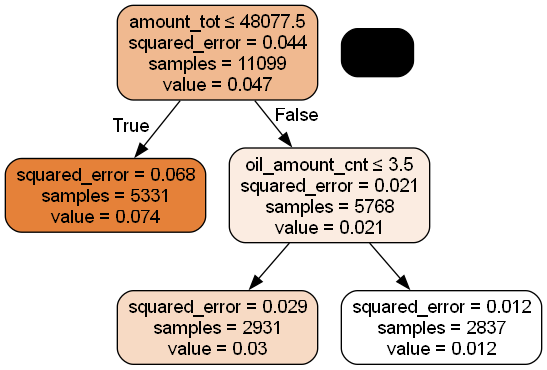

In [54]:
import pydotplus
from sklearn.tree import export_graphviz
from IPython.display import  Image
from six import StringIO
import os
from sklearn import tree

with open("tree.dot", 'w') as f:
    f = export_graphviz(dtree, out_file=f, feature_names=x.columns)

dot_data = StringIO()
export_graphviz(dtree, out_file=dot_data, feature_names=x.columns,
                     class_names=['bad_ind'],
                     filled=True, rounded=True,
                     special_characters=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

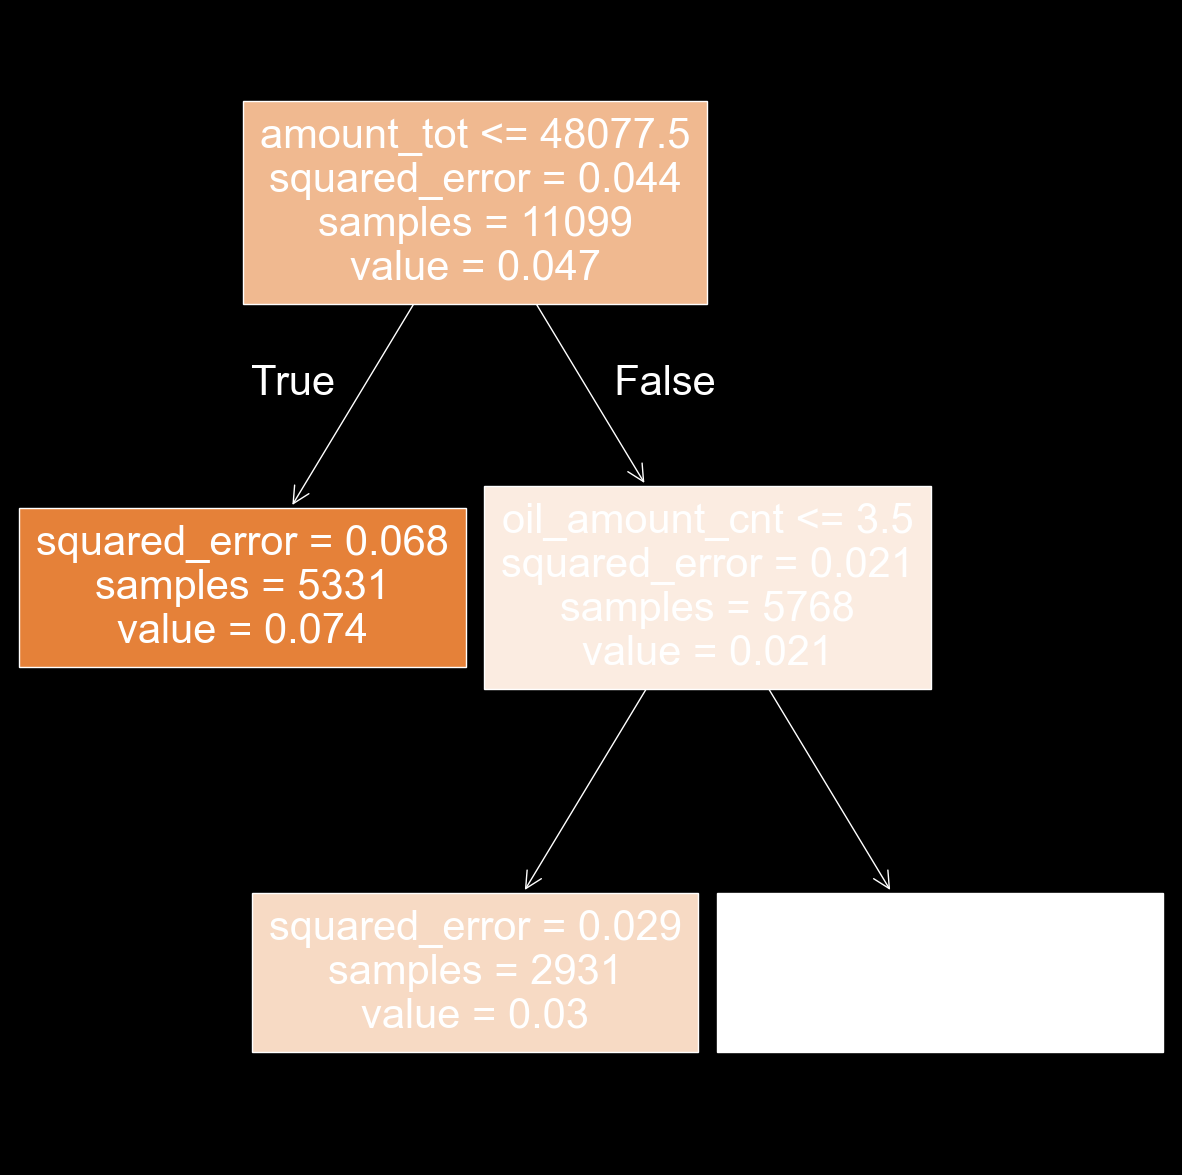

In [55]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(15,15))
plot_tree(dtree, feature_names=x.columns, class_names=['bad_ind'], filled=True)
plt.show()